In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import polars as pl

from trunx.gp3.PG3_model_impl import run_threepg_main
from trunx.config import project_root
from trunx.gp3.run_r3pg import run_comparison_r

from trunx.gp3.plot_function import create_comparison_dataframe

import os
os.chdir(project_root)

import numpy as np

In [2]:
file_path = "./data/data_sspecies_nothinning.xlsx"
# fig, outputs, df = run_threepg_main(file_path, plot_output=True, r_comparison = True)


File path passed: ./data/data_sspecies_nothinning.xlsx
Using custom file: ./data/data_sspecies_nothinning.xlsx
Final stem biomass (Mg/ha): 233.14099
Final LAI: 0.0
Final WS: 233.14099
∂WS/∂alphaCx: 3290.8962
∂WS/∂CoeffCond: -1432.4646
∂WS/∂Y: 348.76562
File path passed: ./data/data_sspecies_nothinning.xlsx
Using custom file: ./data/data_sspecies_nothinning.xlsx


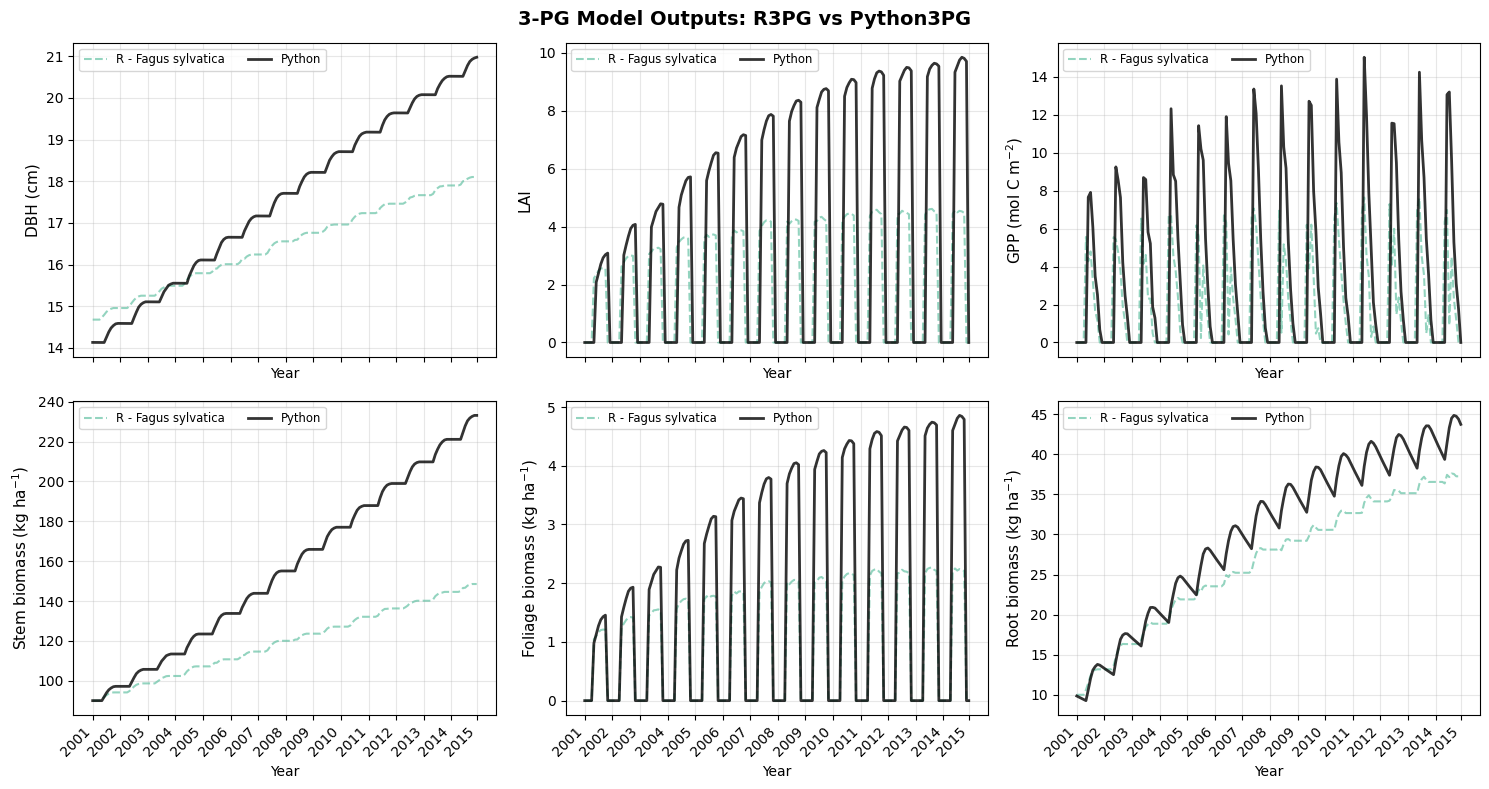

In [3]:
r_df = run_comparison_r(file_path)
fig, outputs = run_threepg_main(file_path, plot_output=True, r_comparison=True)

df = create_comparison_dataframe(r_df, outputs, np.datetime64('2001-01'))

# df.head()

In [69]:
[func for func in r_df.select("variable").unique().to_series().to_list() if "pRx" in func]

[]

In [13]:
r_df.select("variable").unique().to_series().to_list()


['var_9_14',
 'var_7_15',
 'conduct_soil',
 'aero_resist',
 'transp_veg',
 'var_8_11',
 'DrelBiasLCL',
 'biom_incr_foliage',
 'basal_area',
 'var_9_12',
 'f_tmp',
 'var_9_11',
 'tmp_min',
 'var_3_15',
 'biom_loss_foliage',
 'D13CNewPS',
 'f_nutr',
 'var_8_15',
 'height',
 'age',
 'dbh',
 'solar_rad',
 'pFS',
 'npp_fract_foliage',
 'wsweibulllocation',
 'var_1_11',
 'npp_fract_root',
 'Dweibullscale',
 'volume_change',
 'frost_days',
 'irrig_supl',
 'var_8_7',
 'day_length',
 'var_5_13',
 'var_9_9',
 'CVdbhDistribution',
 'f_calpha',
 'prcp_runoff',
 'var_8_9',
 'biom_root',
 'f_sw',
 'var_1_12',
 'var_8_5',
 'var_4_12',
 'tmp_ave',
 'prcp_interc_fract',
 'var_9_8',
 'mort_stress',
 'biom_tree',
 'InterCi',
 'Gc_mol',
 'prcp_interc',
 'var_4_13',
 'var_9_15',
 'vpd_day',
 'wsweibullscale',
 'f_transp_scale',
 'var_9_10',
 'biom_tree_max',
 'layer_id',
 'biom_foliage_debt',
 'var_7_14',
 'DrelBiasCrowndiameter',
 'Dweibullshape',
 'lai_above',
 'lambda_h',
 'var_1_13',
 'D13CTissue',
 'n

Final stem biomass (Mg/ha): 150.22313
Final LAI: 0.0
Final WS: 150.22313
∂WS/∂alphaCx: 1597.627
∂WS/∂CoeffCond: -697.7138
∂WS/∂Y: 169.31473
File path passed: ./data/data_sspecies_nothinning.xlsx
Using custom file: ./data/data_sspecies_nothinning.xlsx


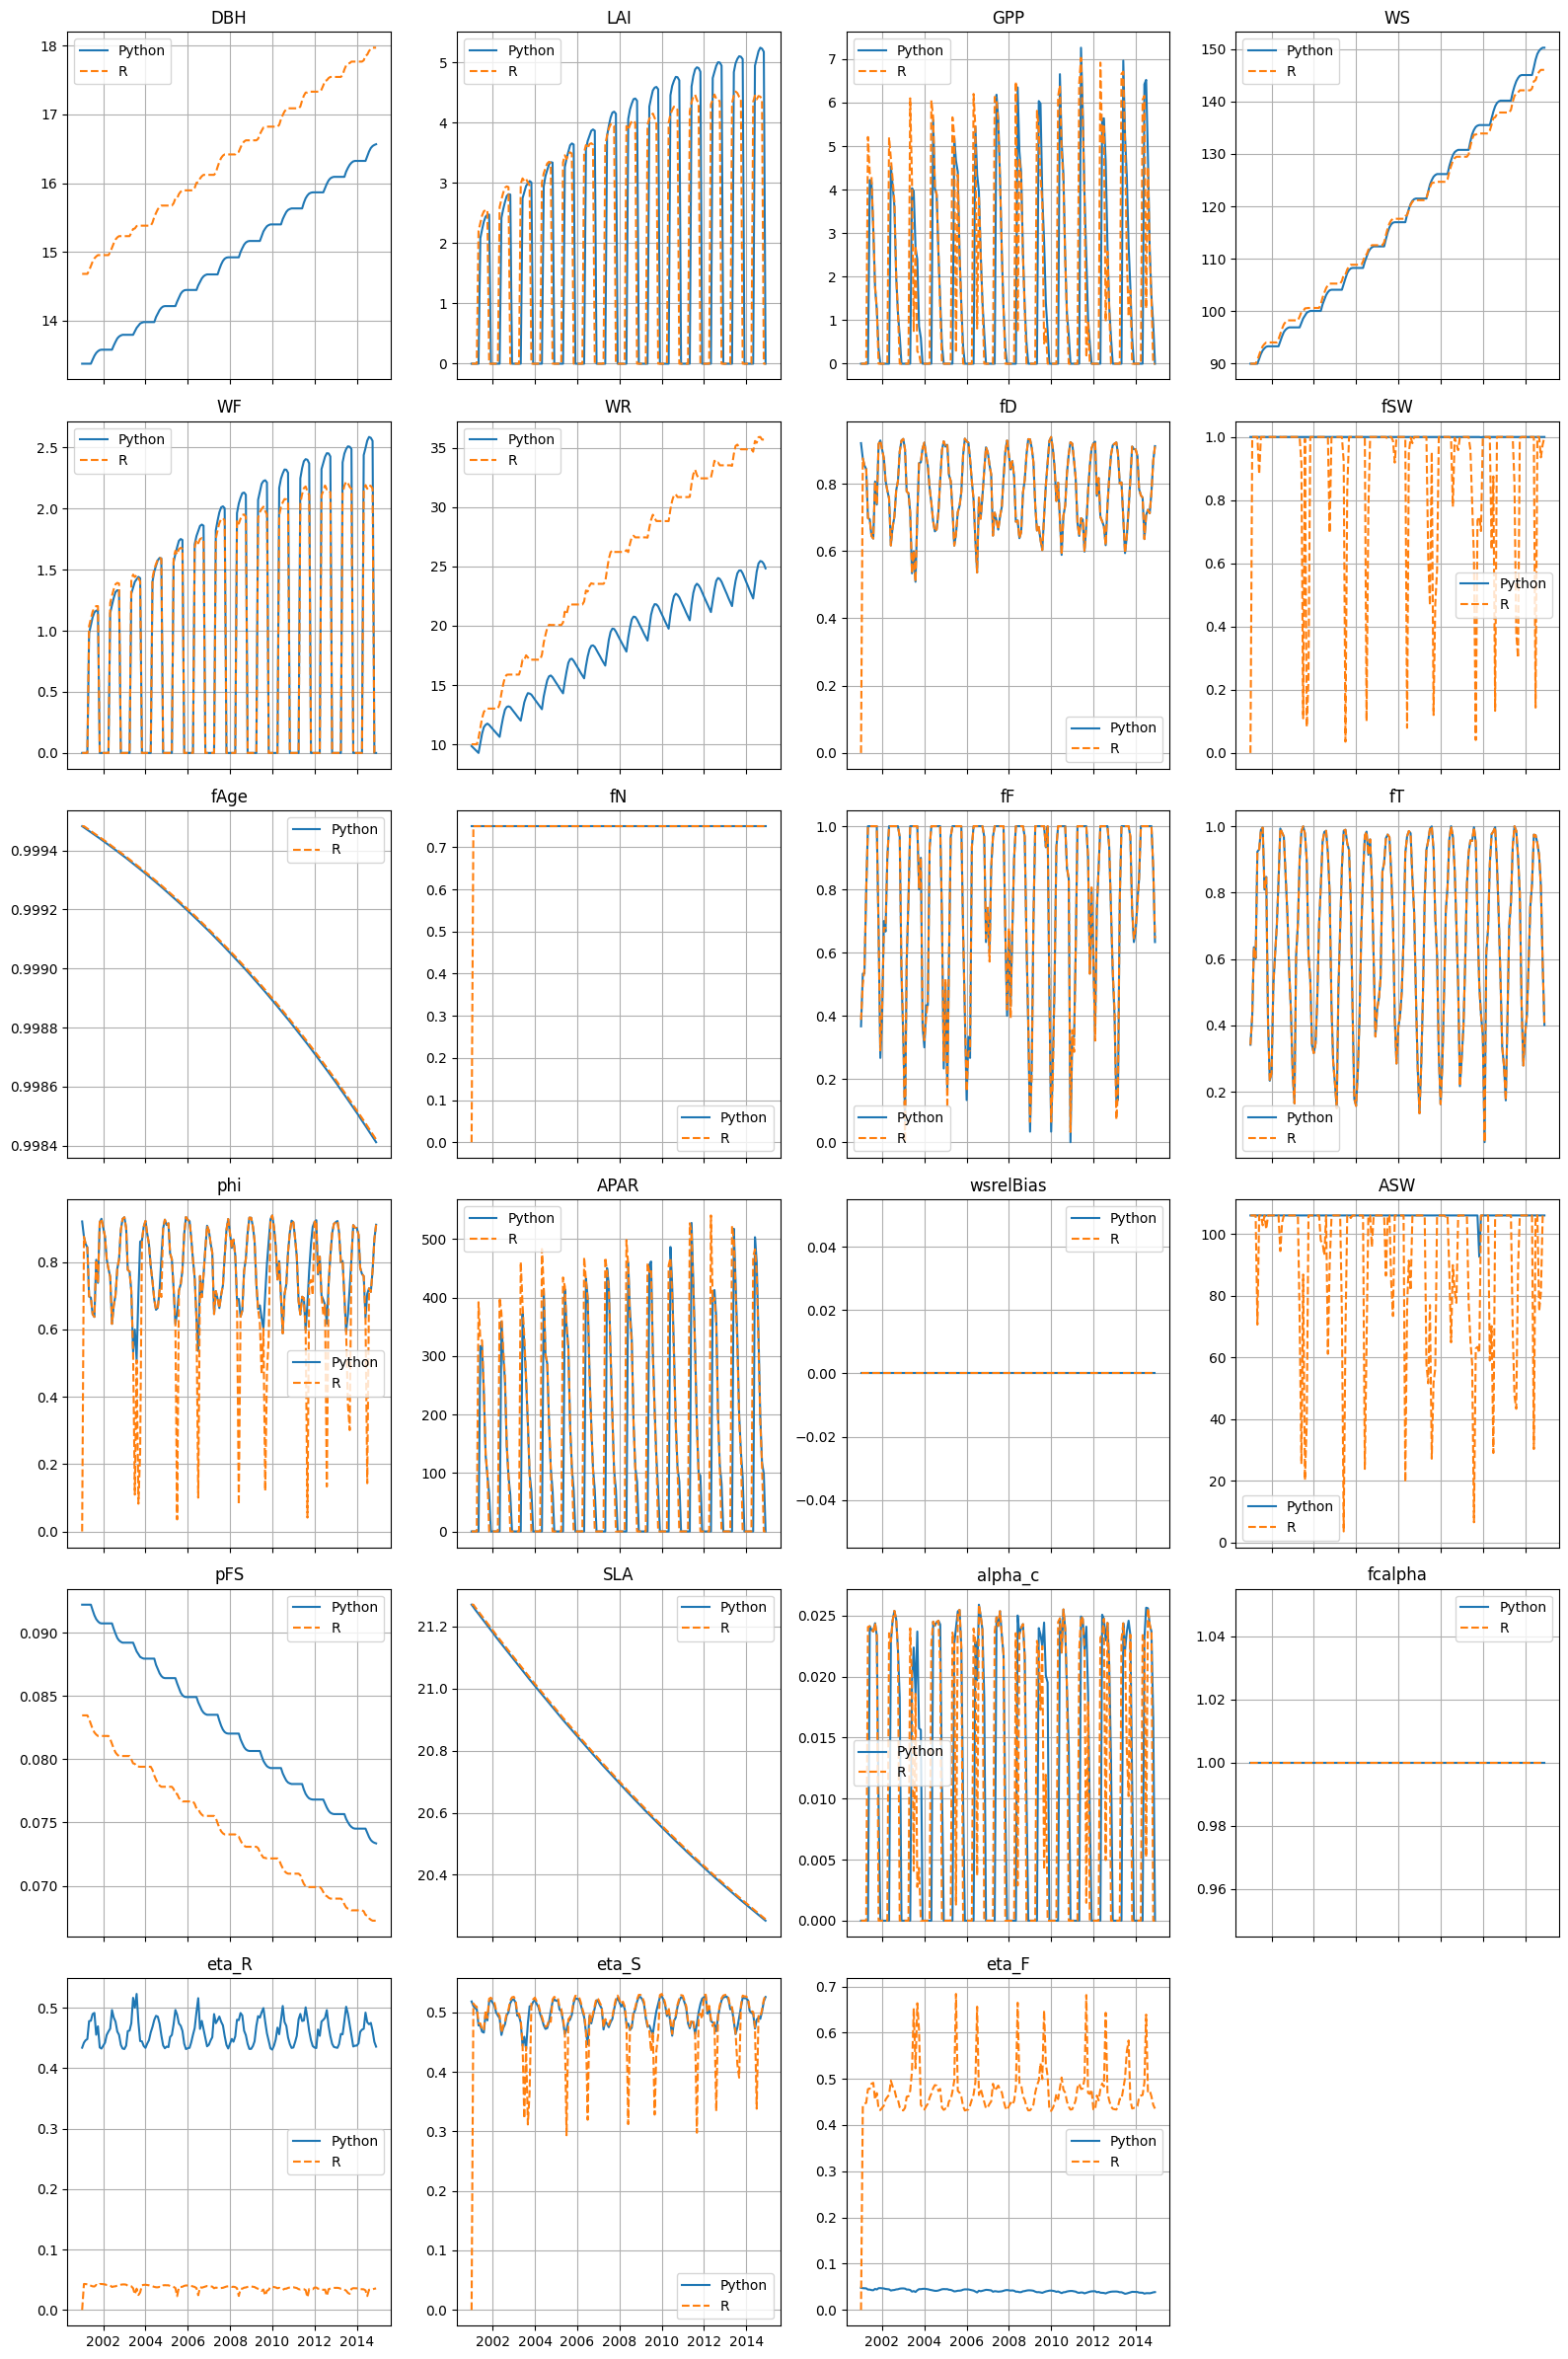

In [16]:
file_path = "./data/data_sspecies_nothinning.xlsx"

fig, outputs = run_threepg_main(file_path, plot_output=False, r_comparison=True)

import matplotlib.pyplot as plt
import pandas as pd

# Ensure Dates column is datetime
df = pd.read_csv("./data/r_python.comparison.csv")
df['Dates'] = pd.to_datetime(df['Dates'])

# Automatically find Python metrics and their R counterparts
py_metrics = [col for col in df.columns if not col.startswith("r_") and col != "Dates"]

# Set fixed number of columns
ncols = 4
n_metrics = len(py_metrics)
nrows = (n_metrics + ncols - 1) // ncols  # Ceiling division for rows

# Create subplots
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols, 4*nrows), sharex=True)
axes = axes.flatten()

for ax, py_col in zip(axes, py_metrics):
    r_col = f"r_{py_col}"
    if r_col in df.columns:
        ax.plot(df['Dates'], df[py_col], label='Python', color='tab:blue')
        ax.plot(df['Dates'], df[r_col], label='R', color='tab:orange', linestyle='--')
        ax.set_title(py_col)
        ax.grid(True)
        ax.legend()

# Remove any unused subplots
for i in range(len(py_metrics), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

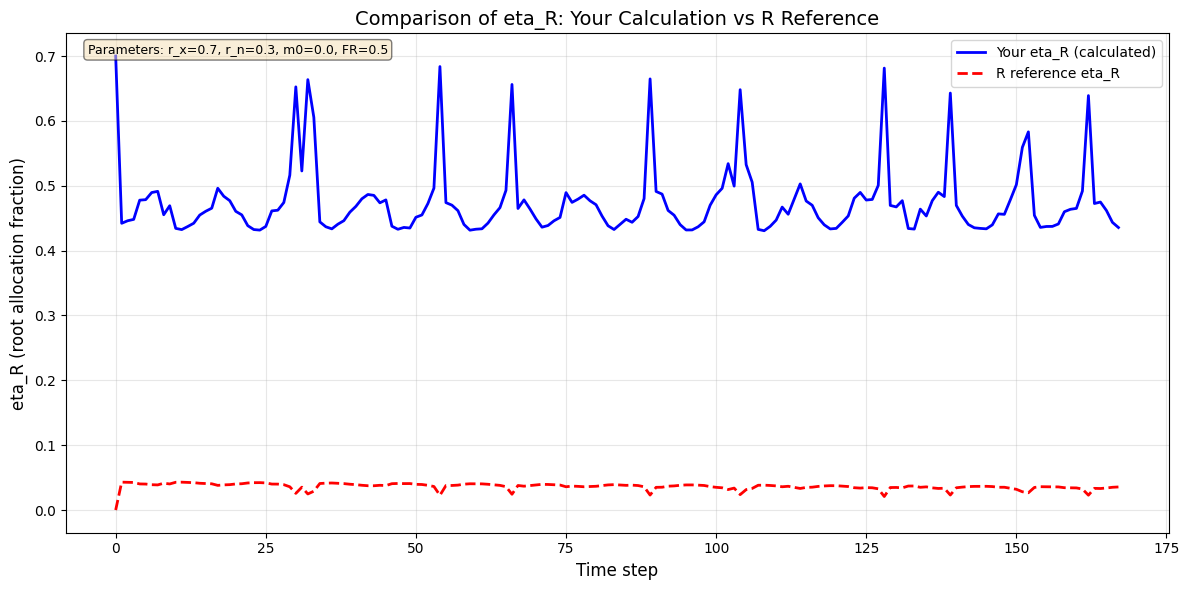

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp

# Load your dataframe
df = pd.read_csv('./data/r_python.comparison.csv')

# Parameters (from your debug output)
r_x = 0.7
r_n = 0.3
m0 = 0.0
FR = 0.5  # From your debug output

# Calculate eta_R using your formula
def calculate_eta_R(phi, r_x, r_n, m0, FR):
    m = m0 + (1.0 - m0) * FR
    eta_R = (r_x * r_n) / (r_n + (r_x - r_n) * phi * m + 1e-8)
    return eta_R

# Get phi values from dataframe
phi_values = df['phi'].values
r_eta_R_values = df['r_eta_R'].values

# Calculate your eta_R
calculated_eta_R = np.array([calculate_eta_R(phi, r_x, r_n, m0, FR) for phi in phi_values])

# Create plot
plt.figure(figsize=(12, 6))

# Plot both eta_R values
plt.plot(df.index, calculated_eta_R, 'b-', label='Your eta_R (calculated)', linewidth=2)
plt.plot(df.index, r_eta_R_values, 'r--', label='R reference eta_R', linewidth=2)

# Add labels and title
plt.xlabel('Time step', fontsize=12)
plt.ylabel('eta_R (root allocation fraction)', fontsize=12)
plt.title('Comparison of eta_R: Your Calculation vs R Reference', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Add text with parameters
params_text = f'Parameters: r_x={r_x}, r_n={r_n}, m0={m0}, FR={FR}'
plt.text(0.02, 0.98, params_text, transform=plt.gca().transAxes, 
         fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('eta_R_comparison.png', dpi=150)
plt.show()


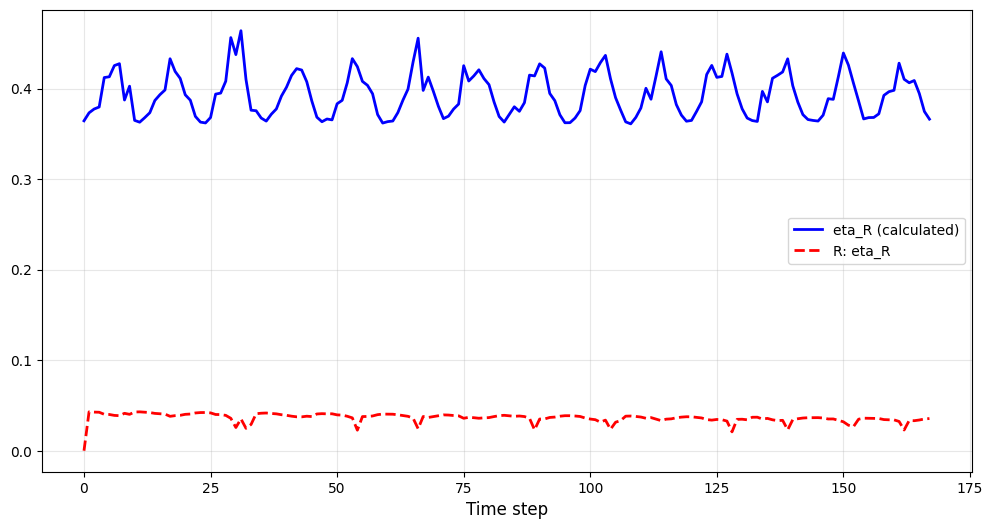

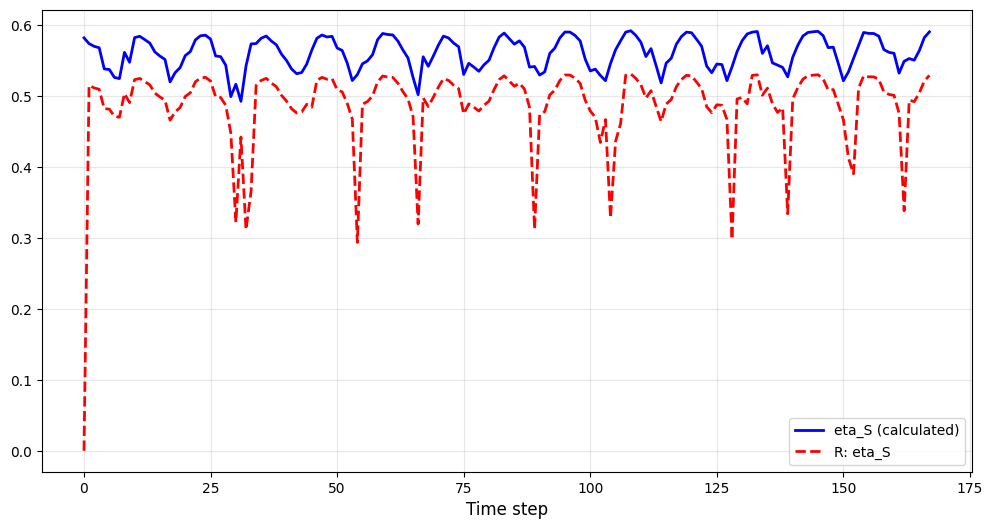

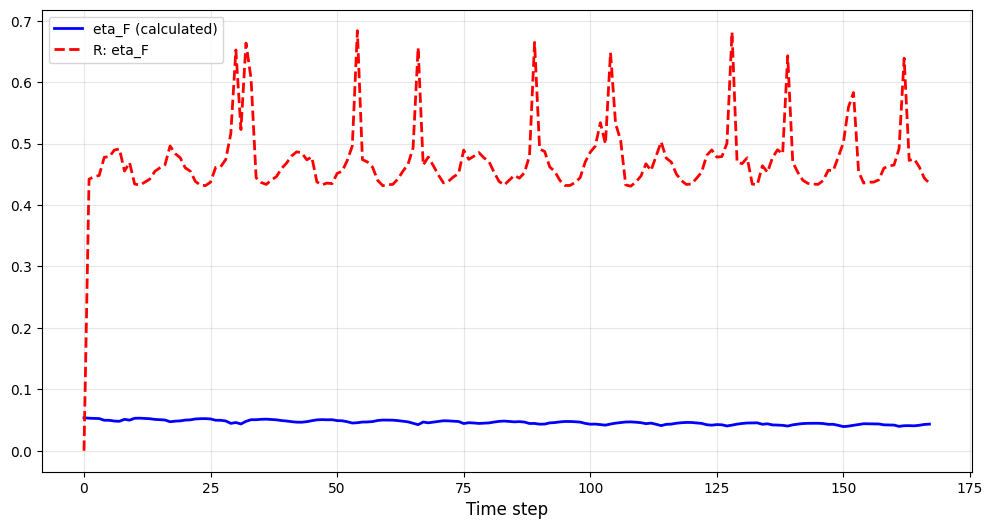

In [ ]:
import jax.numpy as jnp
from trunx.gp3.helper_function import compute_allocation_fraction

# Load your dataframe
df = pd.read_csv('./data/r_python.comparison.csv')

# Parameters (from your debug output)
pRx = jnp.array(0.7)
pRn = jnp.array(0.3)
m0 = jnp.array(0.5)
FR = jnp.array(0.5)
pFS2 = jnp.array(0.7)
pFS20 = jnp.array(0.06)

# Get values from dataframe as JAX arrays
phi_values = jnp.array(df['r_phi'].values)
DBH_values = jnp.array(df['r_DBH'].values)
r_eta_R_values = jnp.array(df['r_eta_R'].values)
r_eta_S_values = jnp.array(df['r_eta_S'].values)
r_eta_F_values = jnp.array(df['r_eta_F'].values)

pFS_all, eta_F_all, eta_S_all, eta_R_all = compute_allocation_fraction(
    FR=FR,
    pRx=pRx,
    pRn=pRn,
    pFS2=pFS2,
    pFS20=pFS20,
    phi_phys=phi_values,
    DBH=DBH_values,
    m0=m0
)

# Convert to numpy for plotting if needed
calculated_pFS = np.array(pFS_all)
calculated_eta_F = np.array(eta_F_all)
calculated_eta_S = np.array(eta_S_all)
calculated_eta_R = np.array(eta_R_all)

# Create plot
plt.figure(figsize=(12, 6))
# Plot both eta_R values
plt.plot(df.index, calculated_eta_R, 'b-', label='eta_R (calculated)', linewidth=2)
plt.plot(df.index, r_eta_R_values, 'r--', label='R: eta_R', linewidth=2)
# Add labels and title
plt.xlabel('Time step', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Create plot
plt.figure(figsize=(12, 6))
# Plot both eta_S values
plt.plot(df.index, calculated_eta_S, 'b-', label='eta_S (calculated)', linewidth=2)
plt.plot(df.index, r_eta_S_values, 'r--', label='R: eta_S', linewidth=2)
# Add labels and title
plt.xlabel('Time step', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Create plot
plt.figure(figsize=(12, 6))
# Plot both eta_R values
plt.plot(df.index, calculated_eta_F, 'b-', label='eta_F (calculated)', linewidth=2)
plt.plot(df.index, r_eta_F_values, 'r--', label='R: eta_F', linewidth=2)
# Add labels and title
plt.xlabel('Time step', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)